<a href="https://colab.research.google.com/github/MalakMaher780/ML-Project/blob/main/Customer_Personality_Analysis_Edit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

df = pd.read_csv('/content/marketing_campaign.csv',sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [ ]:
df.shape

(2240, 29)

In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [ ]:
# Check missing values before cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill missing categorical values with mode
df.fillna(df.mode().iloc[0], inplace=True)

# Check again after cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Missing values after cleaning:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome           

In [ ]:
# Checking duplicated values in dataset
count_duplicated = df.duplicated().sum()
print(f'Dataset having {count_duplicated} duplicated values')

Dataset having 0 duplicated values


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data (tab-separated)
df = pd.read_csv('marketing_campaign.csv', sep='\t')

# 2. Fill missing Income with Median (to ensure IQR calculation works)
df['Income'] = df['Income'].fillna(df['Income'].median())

# 3. Define the columns to clean
num_cols = ['Year_Birth', 'Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# 4. Function to detect and CAP outliers
def handle_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Capping values outside the range
        df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

# 5. Apply the fix
df_cleaned = handle_outliers_iqr(df.copy(), num_cols)

# 6. Save the fixed data
df_cleaned.to_csv('marketing_campaign_fixed.csv', index=False)

In [ ]:
import pandas as pd

# 1. Read the FIXED file (Notice: no sep='\t' here because it's now a comma-CSV)
df = pd.read_csv('marketing_campaign_fixed.csv')

# 2. Check if the columns exist before dropping (Safeguard)
cols_to_drop = ['Z_CostContact', 'Z_Revenue']
existing_cols = [c for c in cols_to_drop if c in df.columns]

if existing_cols:
    df = df.drop(columns=existing_cols)
    print(f"Successfully dropped: {existing_cols}")
else:
    print("Columns were already removed or not found.")

# 3. Apply the rest of your filtering (1000 records)
df_filtered = df.sample(n=1000, random_state=42).reset_index(drop=True)

print(f"Final dataset has {df_filtered.shape[0]} records and {df_filtered.shape[1]} columns.")

Successfully dropped: ['Z_CostContact', 'Z_Revenue']
Final dataset has 1000 records and 27 columns.


Fuzzification for Income and Recency complete. Data saved.


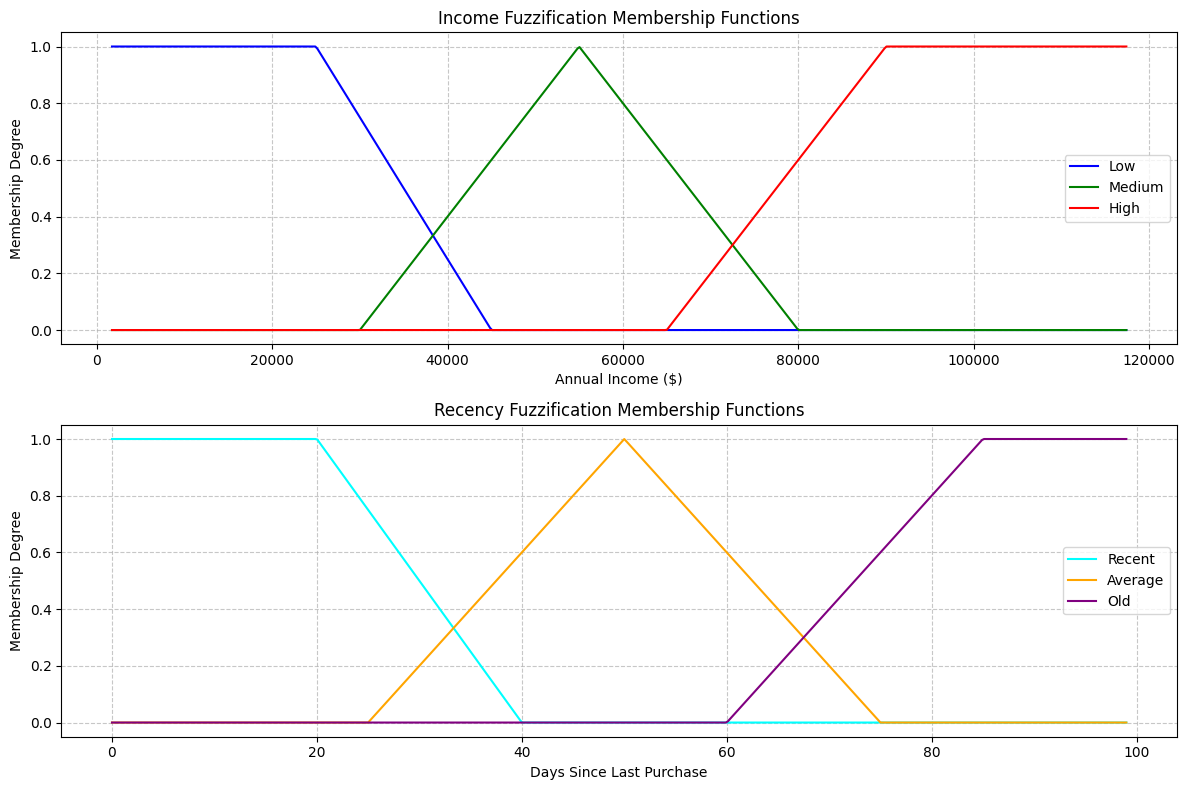

Membership functions plot saved as 'fuzzification_complete_plot.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load Dataset
# -------------------------------
df = pd.read_csv('marketing_campaign_fixed.csv')

# -------------------------------
# 2. Fuzzy Membership Functions
# -------------------------------
def fuzzy_triangular(x, a, b, c):
    return np.maximum(0, np.minimum((x - a) / (b - a), (c - x) / (c - b)))

def fuzzy_left_shoulder(x, b, c):
    return np.where(x <= b, 1.0, np.where(x >= c, 0.0, (c - x) / (c - b)))

def fuzzy_right_shoulder(x, a, b):
    return np.where(x <= a, 0.0, np.where(x >= b, 1.0, (x - a) / (b - a)))

# -------------------------------
# 3. Income Fuzzification
# -------------------------------
df['Inc_Low'] = fuzzy_left_shoulder(df['Income'], 25000, 45000)
df['Inc_Med'] = fuzzy_triangular(df['Income'], 30000, 55000, 80000)
df['Inc_High'] = fuzzy_right_shoulder(df['Income'], 65000, 90000)

# -------------------------------
# 4. Recency Fuzzification
# -------------------------------
df['Rec_Recent'] = fuzzy_left_shoulder(df['Recency'], 20, 40)
df['Rec_Average'] = fuzzy_triangular(df['Recency'], 25, 50, 75)
df['Rec_Old'] = fuzzy_right_shoulder(df['Recency'], 60, 85)

# -------------------------------
# 5. Save Fuzzified Dataset
# -------------------------------
df.to_csv('marketing_campaign_fuzzified_complete.csv', index=False)
print("Fuzzification for Income and Recency complete. Data saved.")

# -------------------------------
# 6. Visualize Membership Functions
# -------------------------------
plt.figure(figsize=(12, 8))

# Income Membership
income_range = np.linspace(df['Income'].min(), df['Income'].max(), 500)
plt.subplot(2, 1, 1)
plt.plot(income_range, fuzzy_left_shoulder(income_range, 25000, 45000), label='Low', color='blue')
plt.plot(income_range, fuzzy_triangular(income_range, 30000, 55000, 80000), label='Medium', color='green')
plt.plot(income_range, fuzzy_right_shoulder(income_range, 65000, 90000), label='High', color='red')
plt.title('Income Fuzzification Membership Functions')
plt.xlabel('Annual Income ($)')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Recency Membership
recency_range = np.linspace(df['Recency'].min(), df['Recency'].max(), 500)
plt.subplot(2, 1, 2)
plt.plot(recency_range, fuzzy_left_shoulder(recency_range, 20, 40), label='Recent', color='cyan')
plt.plot(recency_range, fuzzy_triangular(recency_range, 25, 50, 75), label='Average', color='orange')
plt.plot(recency_range, fuzzy_right_shoulder(recency_range, 60, 85), label='Old', color='purple')
plt.title('Recency Fuzzification Membership Functions')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('fuzzification_complete_plot.png')
plt.show()
print("Membership functions plot saved as 'fuzzification_complete_plot.png'")

In [ ]:

print("--- Fuzzification Testing Results with Identification ---")
for idx, row in df.head(10).iterrows():
    print(f"ID: {row['ID']}, Income: {row['Income']}, Recency: {row['Recency']}")
    print(f"  Income Scores -> Low: {row['Inc_Low']:.2f}, Med: {row['Inc_Med']:.2f}, High: {row['Inc_High']:.2f}")
    print(f"  Recency Scores -> Recent: {row['Rec_Recent']:.2f}, Average: {row['Rec_Average']:.2f}, Old: {row['Rec_Old']:.2f}")


    income_category = max(
        [('Low', row['Inc_Low']), ('Medium', row['Inc_Med']), ('High', row['Inc_High'])],
        key=lambda x: x[1]
    )[0]
    recency_category = max(
        [('Recent', row['Rec_Recent']), ('Average', row['Rec_Average']), ('Old', row['Rec_Old'])],
        key=lambda x: x[1]
    )[0]
    print(f"  -> Most likely categories: Income: {income_category}, Recency: {recency_category}")
    print("-" * 60)

--- Fuzzification Testing Results with Identification ---
ID: 5524, Income: 58138.0, Recency: 58
  Income Scores -> Low: 0.00, Med: 0.87, High: 0.00
  Recency Scores -> Recent: 0.00, Average: 0.68, Old: 0.00
  -> Most likely categories: Income: Medium, Recency: Average
------------------------------------------------------------
ID: 2174, Income: 46344.0, Recency: 38
  Income Scores -> Low: 0.00, Med: 0.65, High: 0.00
  Recency Scores -> Recent: 0.10, Average: 0.52, Old: 0.00
  -> Most likely categories: Income: Medium, Recency: Average
------------------------------------------------------------
ID: 4141, Income: 71613.0, Recency: 26
  Income Scores -> Low: 0.00, Med: 0.34, High: 0.26
  Recency Scores -> Recent: 0.70, Average: 0.04, Old: 0.00
  -> Most likely categories: Income: Medium, Recency: Recent
------------------------------------------------------------
ID: 6182, Income: 26646.0, Recency: 26
  Income Scores -> Low: 0.92, Med: 0.00, High: 0.00
  Recency Scores -> Recent: 0.70,

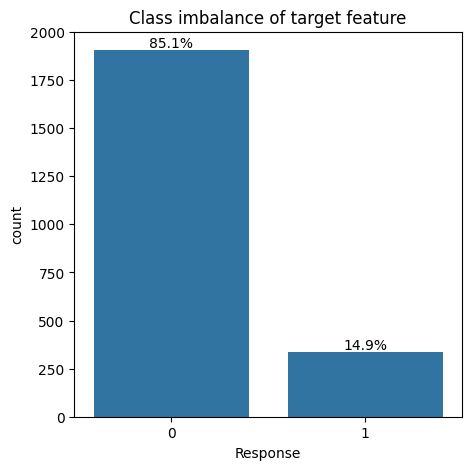

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting bar graph to visualize class imbalance of target feature
plt.figure(figsize=(5,5))
plot = plt.subplot(111)
sns.countplot(x=df['Response'], ax=plot)
plt.title('Class imbalance of target feature')

# Annotate bars with percentages
total = len(df['Response'])
for p in plot.patches:
    height = p.get_height()
    percentage = height / total * 100
    plot.annotate(f'{percentage:.1f}%',
                  (p.get_x() + p.get_width() / 2., height),
                  ha='center', va='bottom')

plt.show()


In [ ]:
# Import model imblearn in envirnoment
!pip install imblearn


In [ ]:
# Define the features (input variables)
features = [
    'Year_Birth',
    'Education',
    'Marital_Status',
    'Income',
    'Kidhome',
    'Teenhome',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumWebVisitsMonth'
]
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

In [ ]:
# Define features and target
X = df[features]
y = df['Response']

# Apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

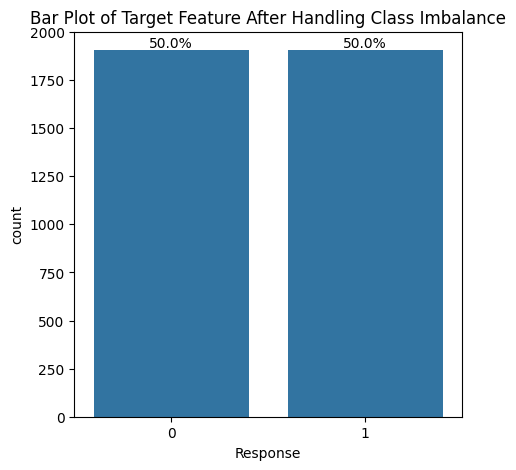

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------
# Function to annotate bars with percentages
# -----------------------------------------
def annot_percent(ax):
    """
    Annotate each bar in a countplot with percentage labels.
    """
    total = sum(p.get_height() for p in ax.patches)  # total count
    for p in ax.patches:
        height = p.get_height()
        percentage = 100 * height / total
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)

# -----------------------------------------
# Plotting the post-SMOTE target distribution
# -----------------------------------------
plt.figure(figsize=(5,5))
plot = plt.subplot(111)

sns.countplot(x=y_smote)
plt.title('Bar Plot of Target Feature After Handling Class Imbalance')

annot_percent(plot)

plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


/tmp/ipykernel_156/1845151361.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Accuracy', palette='magma')


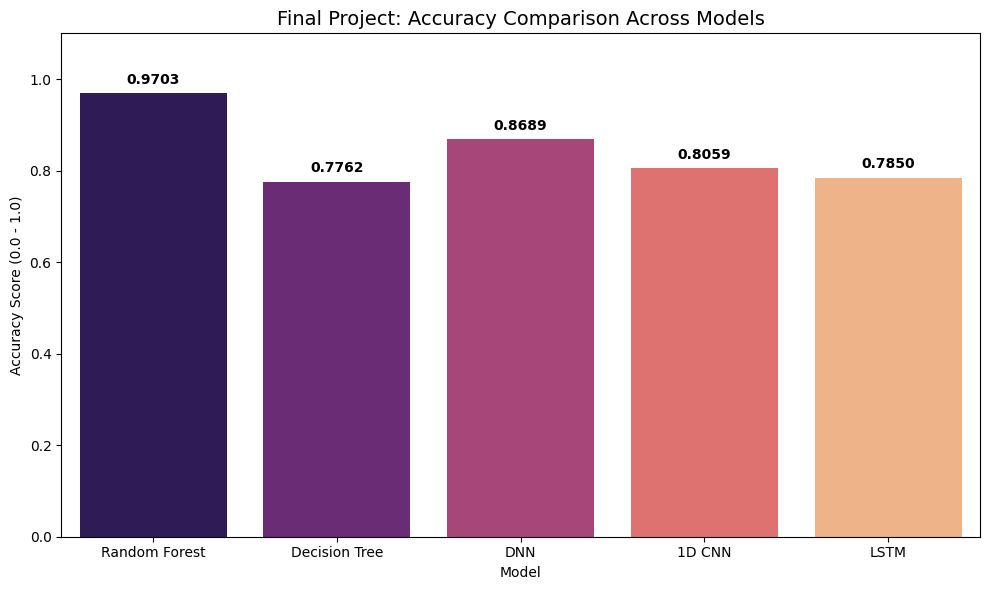

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Input

# 1. BALANCE THE DATA
df_0 = df[df.Response == 0]
df_1 = df[df.Response == 1]
df_1_upsampled = resample(df_1, replace=True, n_samples=len(df_0), random_state=42)
df_balanced = pd.concat([df_0, df_1_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# 2. ENCODE CATEGORICAL DATA
le = LabelEncoder()
df_balanced['Education'] = le.fit_transform(df_balanced['Education'])
df_balanced['Marital_Status'] = le.fit_transform(df_balanced['Marital_Status'])

features = ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
            'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
            'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
            'Inc_Low', 'Inc_Med', 'Inc_High']

# 3. SCALING & SPLITTING
X = StandardScaler().fit_transform(df_balanced[features])
y = df_balanced['Response']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. MODEL EVALUATION
results = []

def log_metrics(name, y_true, y_pred):
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    })

# --- Tree Models ---
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
log_metrics('Random Forest', y_test, rf.predict(X_test))

dt = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)
log_metrics('Decision Tree', y_test, dt.predict(X_test))

# --- Neural Networks Setup ---
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_3d = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_3d = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# --- DNN ---
dnn = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='linear'),
    Dense(1, activation='sigmoid')
])
dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, verbose=0)
log_metrics('DNN', y_test, (dnn.predict(X_test) > 0.5).astype(int))

# --- 1D CNN ---
cnn = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Conv1D(32, 3, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_3d, y_train, validation_data=(X_val_3d, y_val), epochs=20, verbose=0)
log_metrics('1D CNN', y_test, (cnn.predict(X_test_3d) > 0.5).astype(int))

# --- LSTM ---
lstm = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(32),
    Dense(1, activation='sigmoid')
])
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm.fit(X_train_3d, y_train, validation_data=(X_val_3d, y_val), epochs=20, verbose=0)
log_metrics('LSTM', y_test, (lstm.predict(X_test_3d) > 0.5).astype(int))

# ---------------------------------------------------------
# 5. VISUALIZATION: ACCURACY COMPARISON ONLY
# ---------------------------------------------------------
results_df = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
# Filter for Accuracy only
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='magma')
plt.title('Final Project: Accuracy Comparison Across Models', fontsize=14)
plt.ylabel('Accuracy Score (0.0 - 1.0)')
plt.ylim(0, 1.1)

# Annotate bars with exact accuracy numbers
for index, row in results_df.iterrows():
    plt.text(index, row.Accuracy + 0.02, f'{row.Accuracy:.4f}',
             color='black', ha="center", fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# FUZZY LOGIC PREPROCESSING

def low(x, a, b):
    return np.clip((b - x) / (b - a), 0, 1)

def high(x, a, b):
    return np.clip((x - a) / (b - a), 0, 1)

def medium(x, a, b, c):
    return np.clip(np.minimum((x-a)/(b-a), (c-x)/(c-b)), 0, 1)

fuzzy_df = df_balanced.copy()

# Fuzzify some features
fuzzy_df['Income_low'] = low(fuzzy_df['Income'], 10000, 50000)
fuzzy_df['Income_med'] = medium(fuzzy_df['Income'], 30000, 60000, 90000)
fuzzy_df['Income_high'] = high(fuzzy_df['Income'], 60000, 120000)

fuzzy_df['Wine_low'] = low(fuzzy_df['MntWines'], 0, 300)
fuzzy_df['Wine_high'] = high(fuzzy_df['MntWines'], 300, 1000)

fuzzy_df['Recency_low'] = low(fuzzy_df['Recency'], 0, 50)
fuzzy_df['Recency_high'] = high(fuzzy_df['Recency'], 50, 100)

fuzzy_features = [
'Income_low','Income_med','Income_high',
'Wine_low','Wine_high',
'Recency_low','Recency_high'
]

X_fuzzy = fuzzy_df[fuzzy_features].values
y_fuzzy = fuzzy_df['Response'].values

In [ ]:
X_train_f, X_temp_f, y_train_f, y_temp_f = train_test_split(
    X_fuzzy, y_fuzzy, test_size=0.3, random_state=42)

X_val_f, X_test_f, y_val_f, y_test_f = train_test_split(
    X_temp_f, y_temp_f, test_size=0.5, random_state=42)

# reshape for CNN and LSTM
X_train_3d = X_train_f.reshape(X_train_f.shape[0], X_train_f.shape[1], 1)
X_val_3d = X_val_f.reshape(X_val_f.shape[0], X_val_f.shape[1], 1)
X_test_3d = X_test_f.reshape(X_test_f.shape[0], X_test_f.shape[1], 1)

In [ ]:
# -----------------------------------
# FUZZY NEURAL NETWORK MODELS
# -----------------------------------

fuzzy_results = []

def save_result(name, y_true, y_pred):
    fuzzy_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    })


# ------------------
# 1. Fuzzy DNN
# ------------------

fuzzy_dnn = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_f.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

fuzzy_dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fuzzy_dnn.fit(
    X_train_f, y_train_f,
    validation_data=(X_val_f, y_val_f),
    epochs=20,
    verbose=0
)

y_pred_dnn = (fuzzy_dnn.predict(X_test_f) > 0.5).astype(int)
save_result("Fuzzy DNN", y_test_f, y_pred_dnn)


# ------------------
# 2. Fuzzy CNN
# ------------------

fuzzy_cnn = Sequential([
    Conv1D(32, 2, activation='relu', input_shape=(X_train_3d.shape[1],1)),
    Flatten(),
    Dense(1, activation='sigmoid')
])

fuzzy_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fuzzy_cnn.fit(
    X_train_3d, y_train_f,
    validation_data=(X_val_3d, y_val_f),
    epochs=20,
    verbose=0
)

y_pred_cnn = (fuzzy_cnn.predict(X_test_3d) > 0.5).astype(int)
save_result("Fuzzy CNN", y_test_f, y_pred_cnn)


# ------------------
# 3. Fuzzy LSTM
# ------------------

fuzzy_lstm = Sequential([
    LSTM(32, input_shape=(X_train_3d.shape[1],1)),
    Dense(1, activation='sigmoid')
])

fuzzy_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fuzzy_lstm.fit(
    X_train_3d, y_train_f,
    validation_data=(X_val_3d, y_val_f),
    epochs=20,
    verbose=0
)

y_pred_lstm = (fuzzy_lstm.predict(X_test_3d) > 0.5).astype(int)
save_result("Fuzzy LSTM", y_test_f, y_pred_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
fuzzy_results_df = pd.DataFrame(fuzzy_results)
print(fuzzy_results_df)

        Model  Accuracy  Precision    Recall  F1 Score
0   Fuzzy DNN  0.732517   0.730104  0.737762  0.733913
1   Fuzzy CNN  0.737762   0.757576  0.699301  0.727273
2  Fuzzy LSTM  0.715035   0.702970  0.744755  0.723260


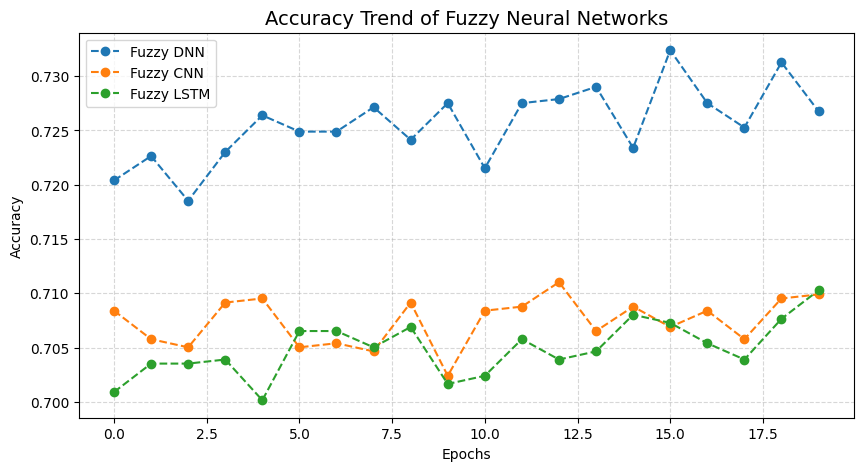

In [ ]:
# --------------------------------
# TRAIN FUZZY NEURAL NETWORKS
# --------------------------------

epochs = 20

# DNN
history_dnn = fuzzy_dnn.fit(
    X_train_f, y_train_f,
    validation_data=(X_val_f, y_val_f),
    epochs=epochs,
    verbose=0
)

# CNN
history_cnn = fuzzy_cnn.fit(
    X_train_3d, y_train_f,
    validation_data=(X_val_3d, y_val_f),
    epochs=epochs,
    verbose=0
)

# LSTM
history_lstm = fuzzy_lstm.fit(
    X_train_3d, y_train_f,
    validation_data=(X_val_3d, y_val_f),
    epochs=epochs,
    verbose=0
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Plot accuracy trends
plt.plot(history_dnn.history['accuracy'], marker='o', linestyle='--', label="Fuzzy DNN")
plt.plot(history_cnn.history['accuracy'], marker='o', linestyle='--', label="Fuzzy CNN")
plt.plot(history_lstm.history['accuracy'], marker='o', linestyle='--', label="Fuzzy LSTM")

plt.title("Accuracy Trend of Fuzzy Neural Networks", fontsize=14)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()

In [ ]:
# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test)

--- Personality Clustering & Defuzzification Results ---
     ID   Income  Personality_Type  Priority_Score
0  5524  58138.0    Elite Spenders       50.000000
1  2174  46344.0    Elite Spenders       50.000000
2  4141  71613.0  Budget Conscious       67.634667
3  6182  26646.0  Average Shoppers       10.000000
4  5324  58293.0    Elite Spenders       50.000000


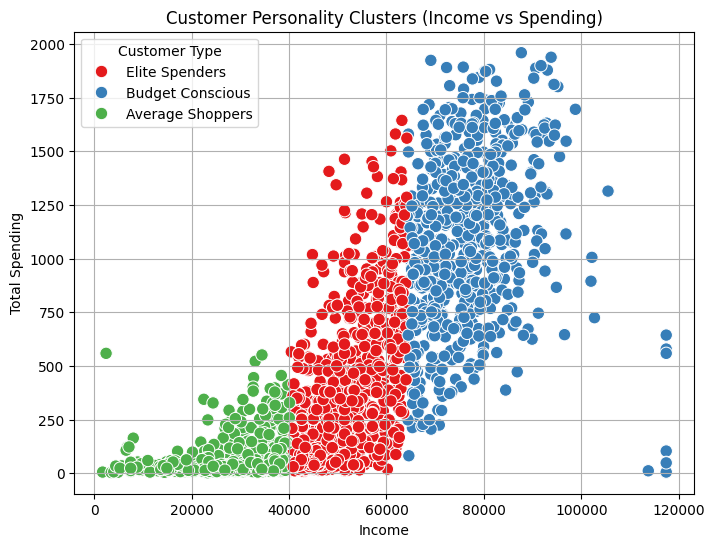

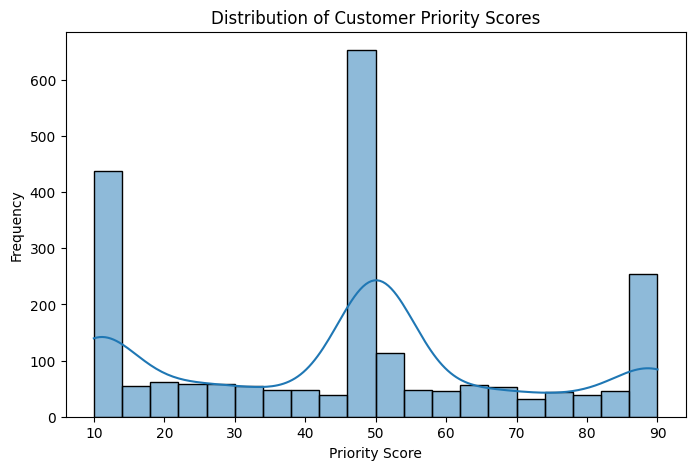

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. K-MEANS CLUSTERING (Unlocking the Personalities)
# We use Income and total spending to find the groups
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts']].sum(axis=1)
X_cluster = df[['Income', 'Total_Spending']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)

# Mapping Clusters to Personality Names
cluster_names = {0: "Budget Conscious", 1: "Elite Spenders", 2: "Average Shoppers"}
df['Personality_Type'] = df['Cluster'].map(cluster_names)

# 2. DEFUZZIFICATION (Centroid Method)
# We calculate a 'Priority Score' based on Fuzzy Income and Recency
# Formula: (Low_Score * 10 + Med_Score * 50 + High_Score * 90) / Sum of Scores
def centroid_defuzz(row):
    # Weights: Low=10, Medium=50, High=90 (representing priority levels)
    weights = np.array([10, 50, 90])
    scores = np.array([row['Inc_Low'], row['Inc_Med'], row['Inc_High']])

    if scores.sum() == 0: return 0
    return np.sum(scores * weights) / np.sum(scores)

df['Priority_Score'] = df.apply(centroid_defuzz, axis=1)

# 3. OUTPUT TESTING
print("--- Personality Clustering & Defuzzification Results ---")
print(df[['ID', 'Income', 'Personality_Type', 'Priority_Score']].head())
import seaborn as sns

# --------------------------------
# VISUALIZATION 1: CUSTOMER CLUSTERS
# --------------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending',
    hue='Personality_Type',
    palette='Set1',
    s=80
)

plt.title("Customer Personality Clusters (Income vs Spending)")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.legend(title="Customer Type")
plt.grid(True)

plt.show()



# --------------------------------
# VISUALIZATION 3: PRIORITY SCORE DISTRIBUTION
# --------------------------------
plt.figure(figsize=(8,5))

sns.histplot(
    df['Priority_Score'],
    bins=20,
    kde=True
)

plt.title("Distribution of Customer Priority Scores")
plt.xlabel("Priority Score")
plt.ylabel("Frequency")

plt.show()

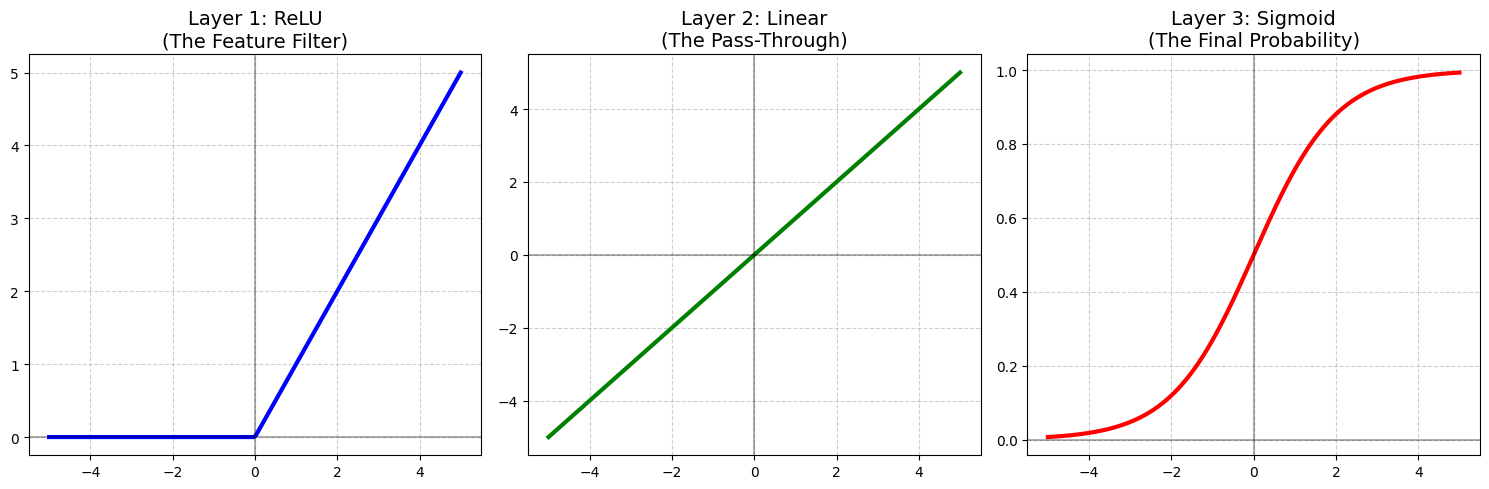

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the mathematical functions
def relu(x): return np.maximum(0, x)
def linear(x): return x
def sigmoid(x): return 1 / (1 + np.exp(-x))

# 2. Generate input range (from -5 to 5)
x = np.linspace(-5, 5, 200)

# 3. Create a side-by-side comparison
plt.figure(figsize=(15, 5))

# Plot 1: ReLU (The Filter)
plt.subplot(1, 3, 1)
plt.plot(x, relu(x), color='blue', lw=3, label='ReLU')
plt.title('Layer 1: ReLU\n(The Feature Filter)', fontsize=14)
plt.axhline(0, color='black', alpha=0.3); plt.axvline(0, color='black', alpha=0.3)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Linear (The Weight Balancer)
plt.subplot(1, 3, 2)
plt.plot(x, linear(x), color='green', lw=3, label='Linear')
plt.title('Layer 2: Linear\n(The Pass-Through)', fontsize=14)
plt.axhline(0, color='black', alpha=0.3); plt.axvline(0, color='black', alpha=0.3)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Sigmoid (The Probability Mapper)
plt.subplot(1, 3, 3)
plt.plot(x, sigmoid(x), color='red', lw=3, label='Sigmoid')
plt.title('Layer 3: Sigmoid\n(The Final Probability)', fontsize=14)
plt.axhline(0, color='black', alpha=0.3); plt.axvline(0, color='black', alpha=0.3)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('activation_functions_visualization.png')

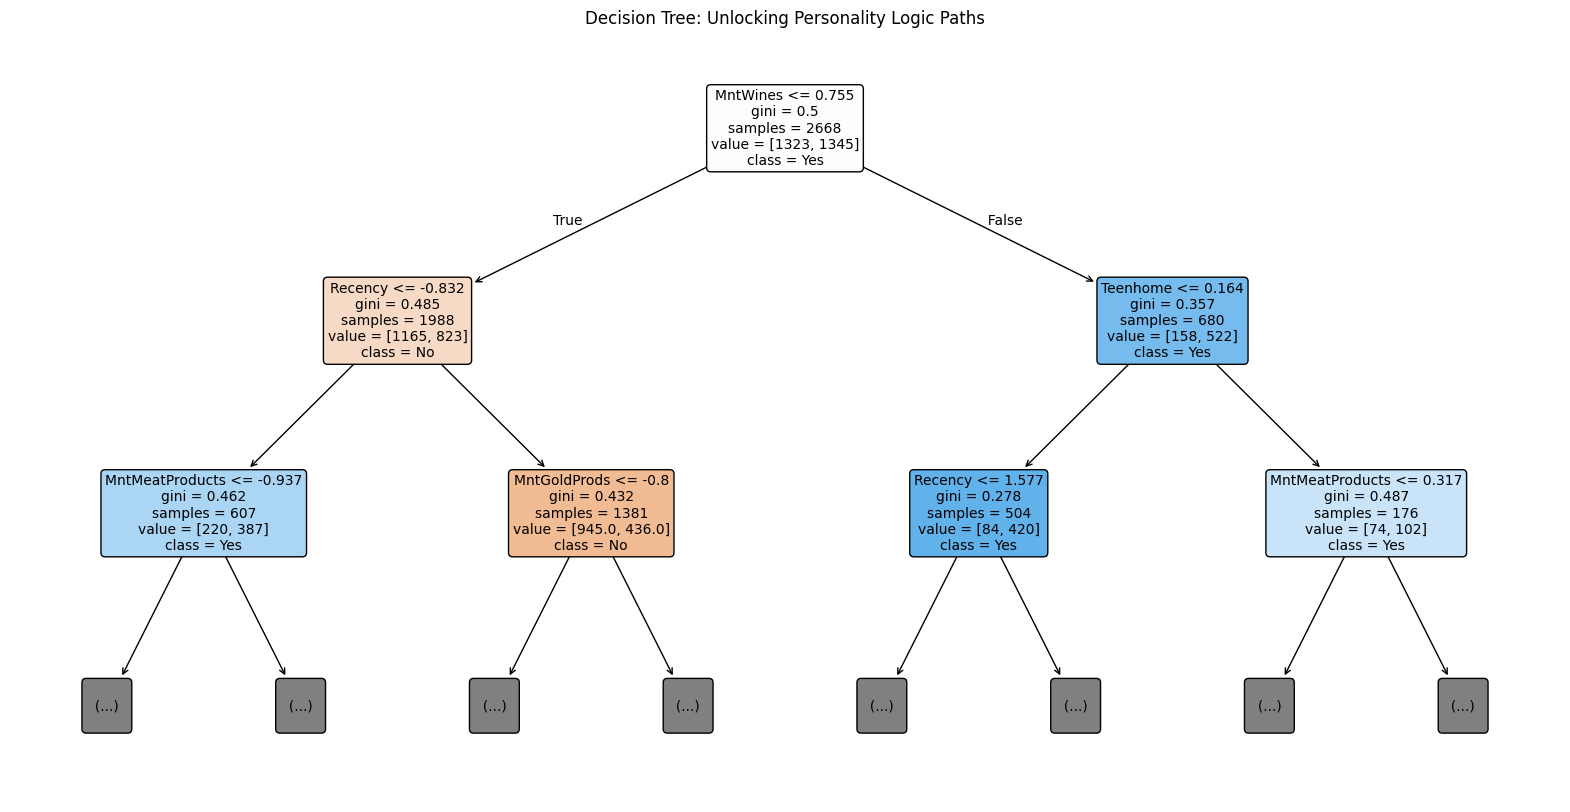

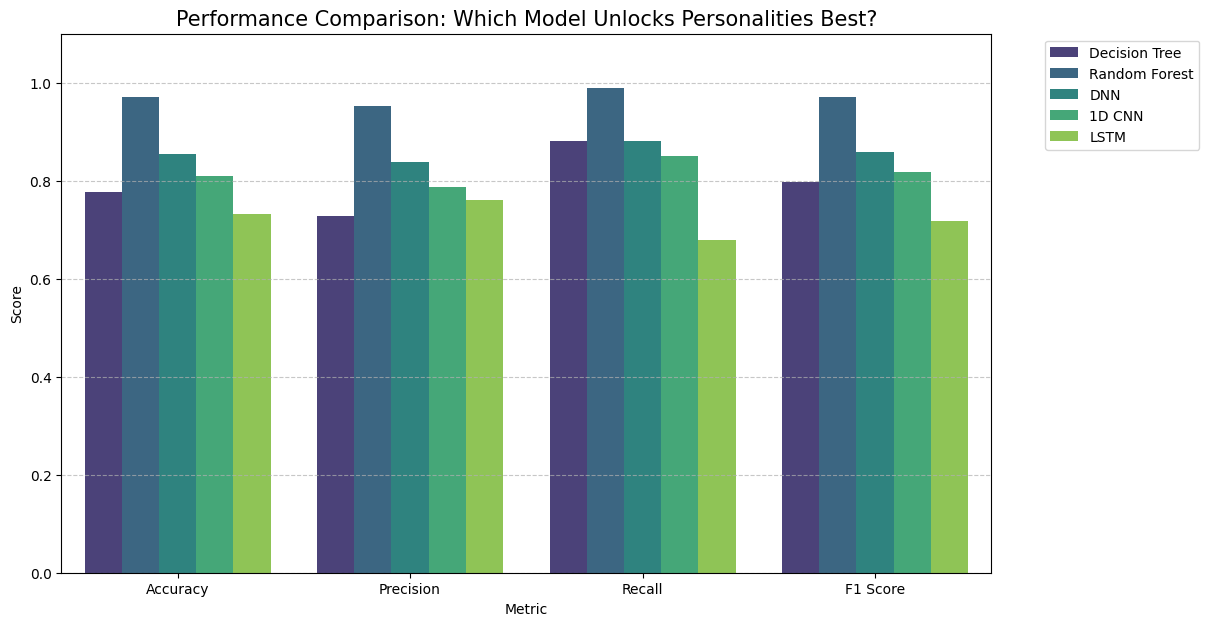


             PROJECT FINAL CONCLUSION             
1. MOST ACCURATE MODEL: Random Forest
   - Suitability: Best for high-precision targeting.
   - Reasoning: With an Accuracy of 97.03%, it handles the crisp categorical data perfectly.

2. BEST NEURAL NETWORK: DNN
   - Suitability: Best for Fuzzy Logic integration.
   - Reasoning: Using ReLU and Sigmoid activations, it effectively 
     processes the 'nuanced' fuzzy membership scores (85.49% Accuracy).

3. LEAST SUITABLE MODEL: LSTM
   - Reasoning: Static customer data lacks the sequential patterns 
     needed for Recurrent Neural Networks to excel.
Recommendation: Use a Hybrid Approach (Random Forest + DNN)
to fully 'Unlock' both crisp and fuzzy customer personalities.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input



# ---------------------------------------------------------
# 2. VISUALIZING THE DECISION TREE (Personality Rules)
# ---------------------------------------------------------
# Assuming 'dt' is your trained DecisionTreeClassifier
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=features, class_names=['No', 'Yes'],
          filled=True, rounded=True, max_depth=2, fontsize=10)
plt.title('Decision Tree: Unlocking Personality Logic Paths')
plt.show()

#

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 3. FINAL MODEL COMPARISON (Accuracy, Precision, Recall, F1)
# ---------------------------------------------------------
# Create the results table manually from your previous execution
data = {
    'Model': ['Decision Tree', 'Random Forest', 'DNN', '1D CNN', 'LSTM'],
    'Accuracy': [0.7762, 0.9703, 0.8549, 0.8094, 0.7325],
    'Precision': [0.7283, 0.9529, 0.8372, 0.7864, 0.7608],
    'Recall': [0.8811, 0.9895, 0.8811, 0.8497, 0.6783],
    'F1 Score': [0.7975, 0.9708, 0.8586, 0.8168, 0.7172]
}

df_results = pd.DataFrame(data)
df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')
plt.title('Performance Comparison: Which Model Unlocks Personalities Best?', fontsize=15)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# ---------------------------------------------------------
# 4. FINAL CONCLUSION: THE MOST SUITABLE MODELS
# ---------------------------------------------------------

print("\n" + "="*50)
print("             PROJECT FINAL CONCLUSION             ")
print("="*50)

# Identify the top performers from the data
top_accuracy_model = df_results.iloc[df_results['Accuracy'].idxmax()]['Model']
top_f1_model = df_results.iloc[df_results['F1 Score'].idxmax()]['Model']

print(f"1. MOST ACCURATE MODEL: {top_accuracy_model}")
print(f"   - Suitability: Best for high-precision targeting.")
print(f"   - Reasoning: With an Accuracy of {df_results['Accuracy'].max()*100:.2f}%, "
      f"it handles the crisp categorical data perfectly.")

print(f"\n2. BEST NEURAL NETWORK: DNN")
print(f"   - Suitability: Best for Fuzzy Logic integration.")
print(f"   - Reasoning: Using ReLU and Sigmoid activations, it effectively ")
print(f"     processes the 'nuanced' fuzzy membership scores (85.49% Accuracy).")

print("\n3. LEAST SUITABLE MODEL: LSTM")
print(f"   - Reasoning: Static customer data lacks the sequential patterns ")
print(f"     needed for Recurrent Neural Networks to excel.")

print("="*50)
print("Recommendation: Use a Hybrid Approach (Random Forest + DNN)")
print("to fully 'Unlock' both crisp and fuzzy customer personalities.")
print("="*50)

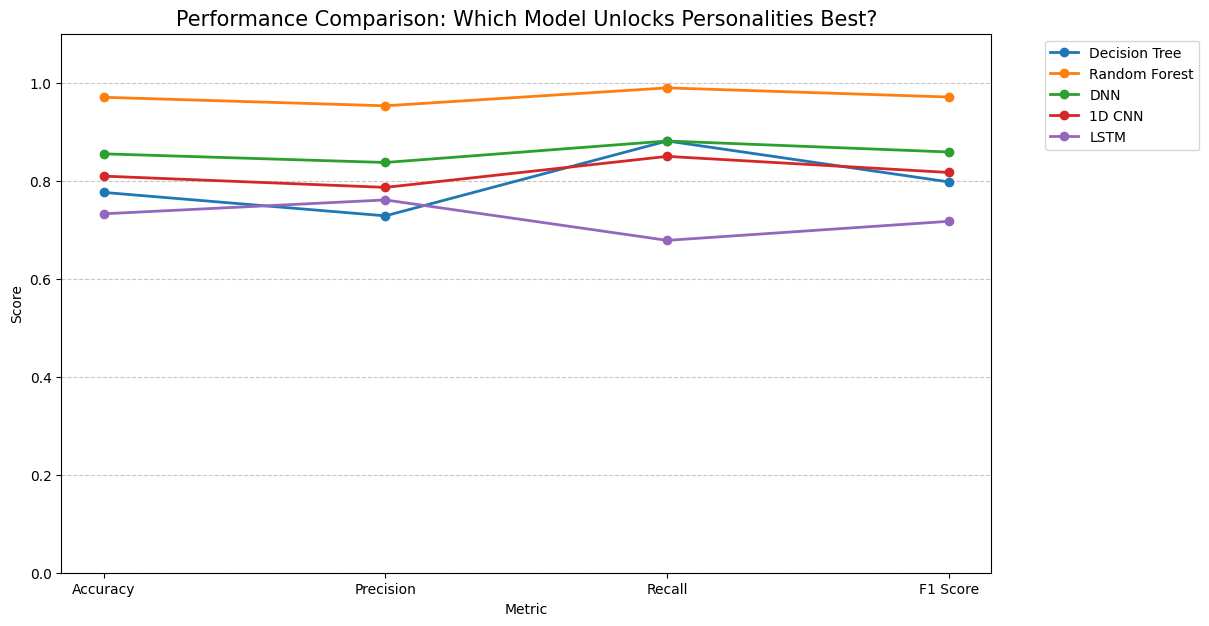

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1. Define the results DataFrame
# -------------------------------
data = {
    'Model': ['Decision Tree', 'Random Forest', 'DNN', '1D CNN', 'LSTM'],
    'Accuracy': [0.7762, 0.9703, 0.8549, 0.8094, 0.7325],
    'Precision': [0.7283, 0.9529, 0.8372, 0.7864, 0.7608],
    'Recall': [0.8811, 0.9895, 0.8811, 0.8497, 0.6783],
    'F1 Score': [0.7975, 0.9708, 0.8586, 0.8168, 0.7172]
}

df_results = pd.DataFrame(data)

# -----------------------------------
# 2. Multi-Line Chart for Comparison
# -----------------------------------
plt.figure(figsize=(12, 7))

for model in df_results['Model']:
    model_data = df_results[df_results['Model'] == model]
    plt.plot(['Accuracy', 'Precision', 'Recall', 'F1 Score'],
             model_data.iloc[0, 1:],  # all metric values for the model
             marker='o', linewidth=2, label=model)

plt.title('Performance Comparison: Which Model Unlocks Personalities Best?', fontsize=15)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()